In [1]:
from copy import deepcopy
from itertools import combinations
from math import comb
from pathlib import Path
import json
import sys

import joblib
from joblib import hash as joblib_hash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "configs" / "data.yaml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load import load_raw_data
from src.data.schema import summarize_schema
from src.data.validate import validate_raw_schema
from src.features.pipeline import BNPFeaturePipeline, EXPERT_SELECTED_FEATURES

with (PROJECT_ROOT / "configs" / "data.yaml").open(encoding="utf-8") as stream:
    data_config = yaml.safe_load(stream)
with (PROJECT_ROOT / "configs" / "features.yaml").open(encoding="utf-8") as stream:
    feature_config = yaml.safe_load(stream)

RANDOM_SEED = int(feature_config.get("random_seed", 42))
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / data_config["processed_dir"]
ARTIFACTS_DIR = PROJECT_ROOT / data_config["artifacts_dir"]
FIGURES_DIR = PROJECT_ROOT / data_config["reports_dir"]
for directory in (PROCESSED_DIR, ARTIFACTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = data_config["target_column"]
ID_COLUMN = data_config["id_column"]
feature_config

{'mode': 'expert',
 'expert_features': {'use_selected_features': True,
  'categorical_1way': True,
  'categorical_2way': True,
  'categorical_3way_v22': True,
  'rounded_numeric_categories': True,
  'numerical_pair_sums': True,
  'high_order_v22_interactions': True,
  'high_order_max_combinations': 1000},
 'target_encoding': {'enabled': False, 'n_splits': 10, 'random_state': 42},
 'unknown_category_value': -1,
 'missing_category_token': '__MISSING__',
 'random_seed': 42}

In [2]:
train_path = PROJECT_ROOT / data_config["raw"]["train_path"]
test_path = PROJECT_ROOT / data_config["raw"]["test_path"]
train_raw, test_raw = load_raw_data(train_path, test_path)
validate_raw_schema(train_raw, test_raw, TARGET, ID_COLUMN)
schema = summarize_schema(train_raw, test_raw, TARGET, ID_COLUMN)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape:  {test_raw.shape}")
print(f"Target: {TARGET!r}; ID: {ID_COLUMN!r}")
print(f"Target distribution: {train_raw[TARGET].value_counts().sort_index().to_dict()}")
print(f"Schema-consistent feature order: {train_raw.drop(columns=TARGET).columns.tolist() == test_raw.columns.tolist()}")
print(f"Train/test dtype mismatches: {list(schema.dtype_mismatches)}")
display(train_raw.head(3))
display(test_raw.head(3))

Train shape: (114321, 133)
Test shape:  (114393, 132)
Target: 'target'; ID: 'ID'
Target distribution: {0: 27300, 1: 87021}
Schema-consistent feature order: True
Train/test dtype mismatches: []


,ID,target,v1,v2,v3,v4,v5,v6,v7,v8,...,v122,v123,v124,v125,v126,v127,v128,v129,v130,v131
0,3,1,1.3357,8.7275,C,3.9210,7.9153,2.5993,3.1769,0.0129,...,8.0000,1.9898,0.0358,AU,1.8041,3.1137,2.0243,0,0.6364,2.8571
1,4,1,NaN,NaN,C,NaN,9.1913,NaN,NaN,2.3016,...,NaN,NaN,0.5989,AF,NaN,NaN,1.9578,0,NaN,NaN
2,5,1,0.9439,5.3101,C,4.4110,5.3262,3.9796,3.9286,0.0196,...,9.3333,2.4776,0.0135,AE,1.7737,3.9222,1.1205,2,0.8831,1.1765


,ID,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v122,v123,v124,v125,v126,v127,v128,v129,v130,v131
0,0,1.3755,11.3611,C,4.2008,6.5770,2.0818,1.7844,0.0111,9.5238,...,7.6190,1.8152,0.0000,AF,1.2924,3.9033,1.4859,0,2.3333,1.4286
1,1,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,I,NaN,NaN,NaN,0,NaN,NaN
2,2,-0.0000,8.2015,C,4.5444,6.5501,1.5584,2.4675,0.0072,7.1429,...,5.7143,1.9709,0.0141,AV,1.1287,5.8442,1.4759,0,1.2632,-0.0000


In [3]:
feature_columns = [column for column in test_raw.columns if column != ID_COLUMN]
numeric_columns = [column for column in feature_columns if pd.api.types.is_numeric_dtype(train_raw[column])]
categorical_columns = [column for column in feature_columns if column not in numeric_columns]
integer_columns = [column for column in numeric_columns if pd.api.types.is_integer_dtype(train_raw[column])]

quality_summary = pd.DataFrame({
    "dtype": train_raw[feature_columns].dtypes.astype(str),
    "missing_train_pct": train_raw[feature_columns].isna().mean().mul(100),
    "missing_test_pct": test_raw[feature_columns].isna().mean().mul(100),
    "train_nunique": train_raw[feature_columns].nunique(dropna=True),
    "test_nunique": test_raw[feature_columns].nunique(dropna=True),
}).sort_values("missing_train_pct", ascending=False)

constant_columns = [column for column in feature_columns if train_raw[column].nunique(dropna=False) <= 1]
test_only_categories = {}
for column in categorical_columns:
    train_values = set(train_raw[column].dropna().astype(str))
    test_values = set(test_raw[column].dropna().astype(str))
    only_test = sorted(test_values - train_values)
    if only_test:
        test_only_categories[column] = only_test

fingerprints = {}
for column in feature_columns:
    hashed = pd.util.hash_pandas_object(train_raw[column], index=False).to_numpy(dtype=np.uint64)
    key = (str(train_raw[column].dtype), int(hashed.sum(dtype=np.uint64)), int(np.bitwise_xor.reduce(hashed)))
    fingerprints.setdefault(key, []).append(column)
duplicate_pairs = []
for candidates in fingerprints.values():
    for left, right in combinations(candidates, 2):
        if train_raw[left].equals(train_raw[right]):
            duplicate_pairs.append((left, right))

print(f"Model predictors: {len(feature_columns)}")
print(f"Numerical: {len(numeric_columns)} (integer storage: {len(integer_columns)})")
print(f"Categorical/string: {len(categorical_columns)}")
print(f"Constant columns: {constant_columns}")
print(f"Exact duplicate column pairs: {duplicate_pairs}")
print(f"Categorical columns with test-only levels: {len(test_only_categories)}")
display(quality_summary.head(15))
display(pd.DataFrame({
    "feature": categorical_columns,
    "train_cardinality": [train_raw[c].nunique(dropna=True) for c in categorical_columns],
    "test_only_levels": [len(test_only_categories.get(c, [])) for c in categorical_columns],
    "missing_train_pct": [100 * train_raw[c].isna().mean() for c in categorical_columns],
}).sort_values("train_cardinality", ascending=False))

Model predictors: 131
Numerical: 112 (integer storage: 4)
Categorical/string: 19
Constant columns: []
Exact duplicate column pairs: []
Categorical columns with test-only levels: 4


,dtype,missing_train_pct,missing_test_pct,train_nunique,test_nunique
v30,str,52.5800,52.7497,7,7
v113,str,48.3761,48.3928,36,36
v102,float64,44.8876,44.8996,62986,63019
v85,float64,44.3331,44.3358,63637,63672
v119,float64,44.3313,44.3349,63638,63676
v123,float64,44.3296,44.3358,63641,63676
v51,float64,44.3296,44.3358,63637,63672
v23,float64,44.3269,44.3323,63638,63674
v115,float64,43.6446,43.6600,64253,64298
v69,float64,43.6446,43.6600,64332,64364


,feature,train_cardinality,test_only_levels,missing_train_pct
1,v22,18210,5209,0.4374
7,v56,122,8,6.0199
18,v125,90,0,0.0674
17,v113,36,1,48.3761
16,v112,22,0,0.3341
12,v79,18,0,0.0000
6,v52,12,0,0.0026
5,v47,10,0,0.0000
9,v71,9,3,0.0000
13,v91,7,0,0.0026


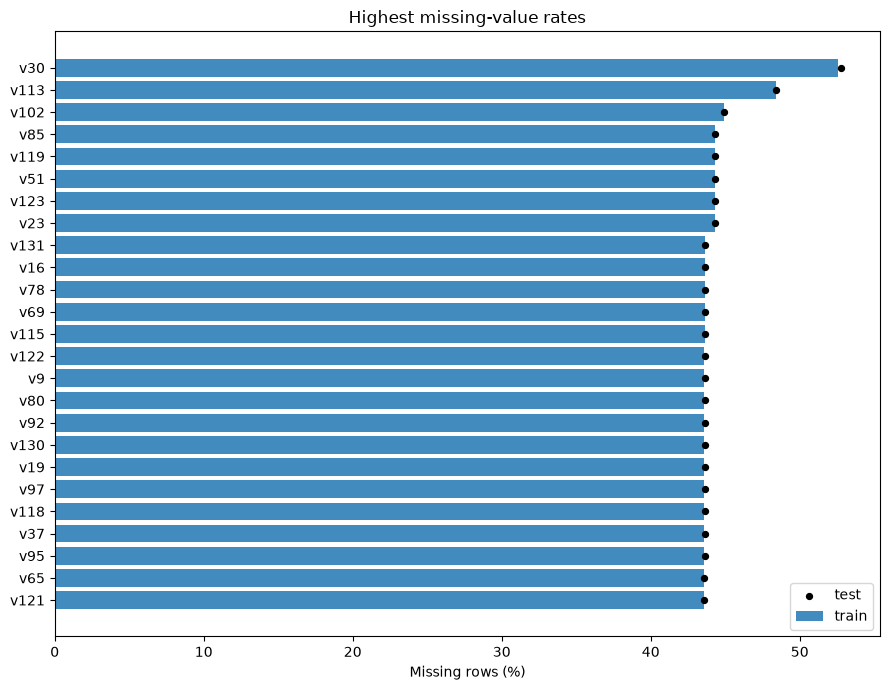

Saved: reports\figures\eda_missingness_top25.png


In [4]:
missing_plot = quality_summary.head(25).sort_values("missing_train_pct")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(missing_plot.index, missing_plot["missing_train_pct"], label="train", alpha=0.85)
ax.scatter(missing_plot["missing_test_pct"], missing_plot.index, label="test", color="black", s=18)
ax.set(title="Highest missing-value rates", xlabel="Missing rows (%)")
ax.legend()
fig.tight_layout()
missingness_figure = FIGURES_DIR / "eda_missingness_top25.png"
fig.savefig(missingness_figure, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {missingness_figure.relative_to(PROJECT_ROOT)}")

In [5]:
missing_expert_features = sorted(set(EXPERT_SELECTED_FEATURES) - set(train_raw.columns))
assert not missing_expert_features, f"Missing upstream-selected features: {missing_expert_features}"

selected_numeric = [c for c in EXPERT_SELECTED_FEATURES if pd.api.types.is_numeric_dtype(train_raw[c])]
selected_categorical = [c for c in EXPERT_SELECTED_FEATURES if c not in selected_numeric]

print(f"Selected raw predictors: {len(EXPERT_SELECTED_FEATURES)}")
print(f"Selected numerical ({len(selected_numeric)}): {selected_numeric}")
print(f"Selected categorical ({len(selected_categorical)}): {selected_categorical}")
print(f"Predictors outside this recipe: {len(feature_columns) - len(EXPERT_SELECTED_FEATURES)}")
selected_profile = quality_summary.loc[EXPERT_SELECTED_FEATURES].copy()
display(selected_profile)
display(train_raw[selected_numeric].describe().T[["min", "max", "mean", "std"]])

integer_notes = pd.DataFrame({
    "feature": ["v38", "v62", "v72", "v129"],
    "preparation_role": ["original numeric"] * 4,
    "note": [
        "discrete/count-like; retain numeric and also create rnum category",
        "discrete/ordinal candidate; retain numeric and also create rnum category",
        "ordered count-like values; retain numeric and also create rnum category",
        "discrete/count-like; retain numeric and also create rnum category",
    ],
})
display(integer_notes)

Selected raw predictors: 25
Selected numerical (12): ['v10', 'v12', 'v14', 'v21', 'v34', 'v38', 'v40', 'v50', 'v62', 'v72', 'v114', 'v129']
Selected categorical (13): ['v22', 'v24', 'v30', 'v31', 'v47', 'v52', 'v56', 'v66', 'v75', 'v79', 'v91', 'v112', 'v113']
Predictors outside this recipe: 106


,dtype,missing_train_pct,missing_test_pct,train_nunique,test_nunique
v10,float64,0.0735,0.0717,112485,112526
v12,float64,0.0752,0.0734,114233,114309
v14,float64,0.0035,0.0017,110472,110677
v21,float64,0.5345,0.5009,113709,113820
v22,str,0.4374,0.4170,18210,18252
v24,str,0.0000,0.0000,5,5
v30,str,52.5800,52.7497,7,7
v31,str,3.0239,3.0526,3,3
v34,float64,0.0971,0.0909,114209,114289
v38,int64,0.0000,0.0000,12,12


,min,max,mean,std
v10,-0.0000,18.5339,1.8830,1.3940
v12,0.0000,18.7106,6.8813,0.9245
v14,-0.0000,20.0000,12.0943,1.4439
v21,0.1062,19.2961,7.0297,1.0723
v34,-0.0000,20.0000,6.4062,2.0252
v38,0.0000,12.0000,0.0909,0.5835
v40,0.0000,20.0000,10.4659,3.1692
v50,-0.0000,20.0000,1.5043,1.1683
v62,0.0000,7.0000,1.0307,0.6962
v72,0.0000,12.0000,1.4318,0.9223


,feature,preparation_role,note
0,v38,original numeric,discrete/count-like; retain numeric and also c...
1,v62,original numeric,discrete/ordinal candidate; retain numeric and...
2,v72,original numeric,ordered count-like values; retain numeric and ...
3,v129,original numeric,discrete/count-like; retain numeric and also c...


In [6]:
n_cat = len(selected_categorical)

expected_high_order = comb(n_cat - 1, 10) if "v22" in selected_categorical else 0

high_order_enabled = feature_config["expert_features"]["high_order_v22_interactions"]
high_order_limit = feature_config["expert_features"]["high_order_max_combinations"]

print(f"Expected v22-including 11-way combinations: {expected_high_order}")
print(f"Enabled: {high_order_enabled}; configured cap: {high_order_limit}")

if high_order_enabled and expected_high_order > high_order_limit:
    raise RuntimeError("High-order feature count exceeds the configured safety cap")

train_ids = train_raw[[ID_COLUMN]].copy()
test_ids = test_raw[[ID_COLUMN]].copy()
y_train = train_raw[TARGET].copy()
X_train_raw = train_raw.drop(columns=TARGET)
X_test_raw = test_raw.copy()

pipeline = BNPFeaturePipeline(feature_config, target_column=TARGET, id_column=ID_COLUMN)
X_train_processed = pipeline.fit_transform(X_train_raw, y_train)
mapping_state_before_test = joblib_hash(pipeline.ordinal_encoder_.mappings_)
fit_count_before_test = pipeline.fit_count_
X_test_processed = pipeline.transform(X_test_raw)

counts = pipeline.expected_counts()
display(pd.Series(counts, name="count").to_frame())
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

Expected v22-including 11-way combinations: 66
Enabled: True; configured cap: 1000


,count
categorical_base,13
categorical_pairs_theoretical,78
categorical_pairs_generated,78
v22_triples_theoretical,66
v22_triples_generated,66
v22_order11_theoretical,66
v22_order11_generated,66
numerical_base,12
numerical_pairs_theoretical,66
numerical_pairs_generated,66


Processed train shape: (114321, 313)
Processed test shape:  (114393, 313)


In [7]:
manifest = pipeline.feature_manifest()
block_rows = []
for group, count in manifest["generated_feature_counts"].items():
    columns = [column for column, origin in manifest["feature_origin"].items() if origin == group]
    block_rows.append({
        "feature_group": group,
        "input_feature_count": (
            len(selected_categorical) if "categorical" in group or group == "high_order_v22_interactions"
            else len(selected_numeric)
        ),
        "generated_feature_count": count,
        "train_block_shape": (len(X_train_processed), count),
        "memory_mib": X_train_processed[columns].memory_usage(deep=True).sum() / 2**20,
    })
block_summary = pd.DataFrame(block_rows)
display(block_summary)

future_example = X_test_raw.iloc[[0]].copy()
future_example.loc[:, "v24"] = "__NEVER_SEEN_IN_TRAIN__"
future_transformed = pipeline.transform(future_example)
assert future_transformed["cat1__v24"].iloc[0] == feature_config["unknown_category_value"]
base_examples = pd.concat(
    [X_train_raw.loc[:4, selected_categorical[:3]], X_train_processed.loc[:4, [f"cat1__{c}" for c in selected_categorical[:3]]]],
    axis=1,
)
display(base_examples)
print("Synthetic unseen v24 code:", int(future_transformed["cat1__v24"].iloc[0]))

,feature_group,input_feature_count,generated_feature_count,train_block_shape,memory_mib
0,original_numerical,12,12,"(114321, 12)",10.4665
1,categorical_1way,13,13,"(114321, 13)",5.6694
2,categorical_2way,13,78,"(114321, 78)",34.0159
3,categorical_3way_v22,13,66,"(114321, 66)",28.7827
4,rounded_numeric_categories,12,12,"(114321, 12)",5.2333
5,numerical_pair_sums,12,66,"(114321, 66)",57.5653
6,high_order_v22_interactions,13,66,"(114321, 66)",28.7827


,v22,v24,v30,cat1__v22,cat1__v24,cat1__v30
0,XDX,C,C,7926,1,1
1,GUV,C,C,12509,1,1
2,FQ,E,NaN,10329,4,3
3,ACUE,D,C,10046,2,1
4,HIT,E,NaN,17864,4,3


Synthetic unseen v24 code: -1


In [8]:
numeric_example_columns = [
    "v10", "v12", "rnum__v10", "rnum__v12", "num2sum__v10__v12"
]

display(X_train_processed[numeric_example_columns].head(8))
print(f"Numerical base features: {counts['numerical_base']}")
print(f"Theoretical pair sums: {counts['numerical_pairs_theoretical']}")
print(f"Actual pair sums: {counts['numerical_pairs_generated']}")

,v10,v12,rnum__v10,rnum__v12,num2sum__v10__v12
0,0.5033,6.0857,37553,11905,6.5890
1,1.3129,6.5076,24936,86479,7.8206
2,0.7659,6.3847,15347,53952,7.1505
3,6.5427,9.6467,14298,5687,16.1893
4,1.0503,6.3201,18362,43915,7.3704
5,1.0503,6.2161,50051,97606,7.2664
6,2.3414,7.7112,11208,31918,10.0525
7,1.8381,6.4245,34730,63459,8.2626


Numerical base features: 12
Theoretical pair sums: 66
Actual pair sums: 66


In [9]:
assert TARGET not in X_train_processed.columns
assert ID_COLUMN not in X_train_processed.columns
assert X_train_processed.columns.tolist() == X_test_processed.columns.tolist()
assert not X_train_processed.columns.duplicated().any()
assert len(X_train_processed) == len(train_raw) == len(y_train)
assert len(X_test_processed) == len(test_raw)
assert X_train_processed.index.equals(y_train.index)
assert not any(pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype) for dtype in X_train_processed.dtypes)
assert pipeline.fit_count_ == fit_count_before_test == 1
assert joblib_hash(pipeline.ordinal_encoder_.mappings_) == mapping_state_before_test
assert all(column.startswith(("cat1__", "cat2__", "cat3__", "cat11__", "rnum__", "num2sum__")) or column in selected_numeric for column in X_train_processed.columns)
assert not feature_config["target_encoding"]["enabled"], "Default notebook output must not use target encoding"

paths = {
    "X_train": PROCESSED_DIR / "X_train_expert.parquet",
    "y_train": PROCESSED_DIR / "y_train.parquet",
    "X_test": PROCESSED_DIR / "X_test_expert.parquet",
    "train_ids": PROCESSED_DIR / "train_ids.parquet",
    "test_ids": PROCESSED_DIR / "test_ids.parquet",
    "manifest": PROCESSED_DIR / "feature_manifest.json",
    "metadata": PROCESSED_DIR / "preprocessing_metadata.json",
    "pipeline": ARTIFACTS_DIR / "bnp_feature_pipeline.joblib",
}

X_train_processed.to_parquet(paths["X_train"], index=False)
y_train.to_frame().to_parquet(paths["y_train"], index=False)
X_test_processed.to_parquet(paths["X_test"], index=False)
train_ids.to_parquet(paths["train_ids"], index=False)
test_ids.to_parquet(paths["test_ids"], index=False)

with paths["manifest"].open("w", encoding="utf-8") as stream:
    json.dump(manifest, stream, indent=2)

metadata = {
    "raw_train_shape": list(train_raw.shape),
    "raw_test_shape": list(test_raw.shape),
    "processed_train_shape": list(X_train_processed.shape),
    "processed_test_shape": list(X_test_processed.shape),
    "missing_values_before": {
        "train_predictors": int(X_train_raw.drop(columns=ID_COLUMN).isna().sum().sum()),
        "test_predictors": int(X_test_raw.drop(columns=ID_COLUMN).isna().sum().sum()),
    },
    "missing_values_after": {
        "train": int(X_train_processed.isna().sum().sum()),
        "test": int(X_test_processed.isna().sum().sum()),
    },
    "memory_bytes": {
        "train": int(X_train_processed.memory_usage(deep=True).sum()),
        "test": int(X_test_processed.memory_usage(deep=True).sum()),
    },
    "target_name": TARGET,
    "id_name": ID_COLUMN,
    "source_implementation": {
        "repository": "https://github.com/atschalz/dc_tabeval",
        "commit": "433b01652bc1f3165048c55912b99fa8c633d583",
        "class": "BNPParibasCardifClaimsManagement",
        "kaggle_reference": "https://www.kaggle.com/code/confirm/xfeat-catboost-cpu-only",
    },
    "intentional_deviations": [
        "All learned state is fitted on train only; test is transform-only.",
        "Missing and unknown categories are distinct and explicit.",
        "Numeric coarsening handles NaN/scientific notation rather than blindly slicing strings.",
        "Stable uint64 signatures reduce interaction-state memory; ordinal maps remain train-fitted.",
        "High-order v22 interactions are configurable and guarded by a combination cap.",
        "No xfeat or dc_tabeval runtime dependency is required.",
    ],
}
with paths["metadata"].open("w", encoding="utf-8") as stream:
    json.dump(metadata, stream, indent=2)
joblib.dump(pipeline, paths["pipeline"], compress=3)

reloaded_train = pd.read_parquet(paths["X_train"])
reloaded_y = pd.read_parquet(paths["y_train"])
reloaded_test = pd.read_parquet(paths["X_test"])
reloaded_train_ids = pd.read_parquet(paths["train_ids"])
reloaded_test_ids = pd.read_parquet(paths["test_ids"])
reloaded_pipeline = joblib.load(paths["pipeline"])
assert reloaded_train.shape == X_train_processed.shape
assert reloaded_test.shape == X_test_processed.shape
assert reloaded_train.columns.tolist() == reloaded_test.columns.tolist() == pipeline.get_feature_names_out()
assert reloaded_y[TARGET].tolist() == y_train.tolist()
assert reloaded_train_ids[ID_COLUMN].tolist() == train_ids[ID_COLUMN].tolist()
assert reloaded_test_ids[ID_COLUMN].tolist() == test_ids[ID_COLUMN].tolist()
assert reloaded_pipeline.get_feature_names_out() == pipeline.get_feature_names_out()

validation_summary = pd.Series({
    "raw_train_shape": str(train_raw.shape),
    "raw_test_shape": str(test_raw.shape),
    "processed_train_shape": str(X_train_processed.shape),
    "processed_test_shape": str(X_test_processed.shape),
    "numerical_output_features": sum(v for k, v in manifest["generated_feature_counts"].items() if k in {"original_numerical", "numerical_pair_sums"}),
    "categorical_derived_features": len(manifest["categorical_feature_names"]),
    "total_features": X_train_processed.shape[1],
    "remaining_train_nan": int(X_train_processed.isna().sum().sum()),
    "remaining_test_nan": int(X_test_processed.isna().sum().sum()),
    "train_memory_mib": round(X_train_processed.memory_usage(deep=True).sum() / 2**20, 2),
    "test_memory_mib": round(X_test_processed.memory_usage(deep=True).sum() / 2**20, 2),
    "pipeline_fit_count": pipeline.fit_count_,
    "reload_checks": "passed",
    "all_assertions": "passed",
})
display(validation_summary.to_frame("value"))
print("Saved artifacts:")
for path in paths.values():
    print(" -", path.relative_to(PROJECT_ROOT))

,value
raw_train_shape,"(114321, 133)"
raw_test_shape,"(114393, 132)"
processed_train_shape,"(114321, 313)"
processed_test_shape,"(114393, 313)"
numerical_output_features,78
categorical_derived_features,235
total_features,313
remaining_train_nan,12089
remaining_test_nan,11367
train_memory_mib,170.5200


Saved artifacts:
 - data\processed\X_train_expert.parquet
 - data\processed\y_train.parquet
 - data\processed\X_test_expert.parquet
 - data\processed\train_ids.parquet
 - data\processed\test_ids.parquet
 - data\processed\feature_manifest.json
 - data\processed\preprocessing_metadata.json
 - models\artifacts\bnp_feature_pipeline.joblib
